[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RadimKozl/JLNN/blob/main/examples/JLNN_xarray_rule_monitoring_moe.ipynb)

# **JLNN + Xarray: Real-time Rule Emergence Monitoring in Nano-MoE**

### **The Vision: Neuro-symbolic Self-Reflection**
In modern Mixture-of-Experts (MoE) architectures, the **router** is often a black box, making it difficult to understand why a specific expert was chosen. This tutorial demonstrates a **Neuro-symbolic Monitoring System** using **JLNN (JAX Logical Neural Networks)**.

By evaluating fuzzy logic rules over neural activations in real-time, we can audit the model's "sanity" and logical consistency during the training process.

**Key Technologies:**
* **Nano-MoE:** A custom Transformer with Causal Self-Attention and a Mixture-of-Experts layer.
* **JLNN:** A framework for learning and executing fuzzy logic rules within the JAX ecosystem.
* **Xarray:** A powerful library for N-dimensional telemetry, used here to track rule bounds $[L, U]$ across training iterations.



---------------------------------------------------------------

## ***Instalation & Imports***

----------------------------------------------------------------

In [1]:
def setup_jlnn_tpu_environment():
    print("🧹 Cleaning environment from potential conflicts...")
    # We will remove the old JAX to force a clean TPU installation
    !pip uninstall -y jax jaxlib --quiet

    print("🚀 Installing JAX with TPU support...")
    # Install TPU specific version
    !pip install "jax[tpu]" -f https://storage.googleapis.com/jax-releases/libtpu_releases.html --quiet

    print("📦 Installing jax-lnn and visual tools...")
    # Installing your project directly from GitHub
    !pip install git+https://github.com/RadimKozl/JLNN.git --quiet
    !pip install seaborn xarray --quiet

    print("\n🔄 RESTARTING KERNEL to apply TPU changes...")
    os.kill(os.getpid(), 9)

STEP: Check/Installation

In [3]:
try:
    import jlnn
    import os
    import jax
    # Checking if we see TPU
    if 'TPU_NAME' in os.environ:
        import jax.tools.colab_tpu
        jax.tools.colab_tpu.setup_tpu()

    print(f"✅ jax-lnn is ready.")
    print(f"✅ Devices: {jax.devices()}")
    # Here you should see: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), ...]

except (ImportError, RuntimeError):
    setup_jlnn_tpu_environment()

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:91: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


✅ jax-lnn is ready.
✅ Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


In [4]:
import jax
import os

if 'TPU_NAME' in os.environ:
    import jax.tools.colab_tpu
    jax.tools.colab_tpu.setup_tpu()

print(f"Confirmed Devices: {jax.devices()}")

Confirmed Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


### ***Download real data (TinyShakespeare)***

In [5]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O input.txt

--2026-05-03 18:39:43--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.04s   

2026-05-03 18:39:44 (26.5 MB/s) - ‘input.txt’ saved [1115394/1115394]



### ***Imports***

In [6]:
import jax
import jax.numpy as jnp
from flax import nnx
import optax
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

# JLNN imports
from jlnn.symbolic.compiler import LNNFormula
from jlnn.nn.constraints import apply_constraints, clip_predicates
from jlnn.training.losses import total_lnn_loss

----------------------------------------------

## ***DATASET SETUP (TinyShakespeare)***

---------------------------------------------

We use a character-level language modeling task to demonstrate MoE routing.

In [7]:
with open('input.txt', 'r') as f: text = f.read()

In [8]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
data = jnp.array(encode(text), dtype=jnp.int32)

In [9]:
print(f"Dataset loaded: {len(data)} characters, dictionary: {vocab_size} unique characters.")

Dataset loaded: 1115394 characters, dictionary: 65 unique characters.


In [10]:
def get_batch(batch_size=64, block_size=128):
    """Generates a random batch of data for training."""
    ix = np.random.randint(0, len(data) - block_size, (batch_size,))
    return jnp.stack([data[i:i+block_size] for i in ix]), jnp.stack([data[i+1:i+block_size+1] for i in ix])

### **The Audit Logic: Comprehensive Rule Monitoring**

Instead of relying on a single heuristic, we define a set of formal logic rules to monitor the **Neuro-symbolic Emergence** within the MoE layer. This audit tracks the interaction between routing efficiency, expert utilization, and training stability across 6 distinct logical dimensions.

#### ***Key Monitored Hypotheses:***

- **Expert Specialization:** High routing confidence combined with low activation entropy signals that experts are becoming niche-specific.
- **Systemic Imbalance:** Detection of high expert imbalance paired with increasing weight magnitudes (a warning sign of expert collapse).
- **Routing Maturity:** Stable or decreasing loss combined with decisive routing indicates a maturing modular system.
- **Underutilization:** Identifying states where the model is neither confident nor decisive, failing to leverage its modular capacity.

#### ***Core Symbolic Rules (JLNN Syntax):***

1. `0.85 :: high_routing_confidence & low_activation_entropy` **(Specialization)**
2. `0.75 :: high_expert_imbalance & increasing_weight_magnitude` **(Imbalance Risk)**
3. `0.80 :: high_routing_confidence & stable_loss` **(Routing Stability)**
4. `0.70 :: decreasing_loss & low_activation_entropy` **(Learning Progress)**
5. `0.65 :: ~low_activation_entropy & ~high_routing_confidence` **(Underutilization)**
6. `0.75 :: low_activation_entropy & ~high_expert_imbalance` **(Healthy Specialization)**

#### ***Interpreting the Audit:***

By evaluating these fuzzy logic rules over neural activations in real-time, the monitor creates a **"Logical Self-Reflection"** layer. We don't just see numbers; we see the "truth" of the training process. When the truth values ($[L,U]$ intervals) for the positive rules (1, 3, 4, 6) stabilize near $1.0$, the neuro-symbolic audit confirms that the MoE architecture has successfully transitioned from stochastic routing to structured, specialized behavior.

----------------------------------------------

## ***NEURO-SYMBOLIC AUDIT: JLNN Rules***

---------------------------------------------

In [11]:
class MoELogicMonitor(nnx.Module):
    """Modular monitor inspired by QuantumLogicModel, holding independent LNN formulas."""
    def __init__(self, rules, rngs):
        self.rules = nnx.List([LNNFormula(r, rngs) for r in rules])
    def __call__(self, x):
        return jnp.stack([r(x) for r in self.rules])

Definition of Fuzzy Logic Rules for MoE Diagnostics.
Define your 6 rules as a list of strings.

In [12]:
rule_strings = [
    "0.85 :: high_routing_confidence & low_activation_entropy",
    "0.75 :: high_expert_imbalance & increasing_weight_magnitude",
    "0.80 :: high_routing_confidence & stable_loss",
    "0.70 :: decreasing_loss & low_activation_entropy",
    "0.65 :: ~low_activation_entropy & ~high_routing_confidence",
    "0.75 :: low_activation_entropy & ~high_expert_imbalance"
]

In [13]:
monitor = MoELogicMonitor(rule_strings, nnx.Rngs(45))

In [14]:
def fuzzy_ramp(x, slope=12, offset=0.5):
    """Maps a scalar value to a [Lower, Upper] fuzzy interval."""
    L = jax.nn.sigmoid(slope * (x - (offset + 0.05)))
    U = jax.nn.sigmoid(slope * (x - (offset - 0.05)))
    return jnp.stack([L, U], axis=-1).reshape(1, 1, 2)

In [15]:
def safe_extract(data_or_node):
    """
    Robustly extracts [L, U] intervals.
    Handles both JLNN Nodes (via .output/.value) and raw JAX/NumPy arrays.
    """
    # If it's a node, get its data. If it's already an array, use it directly.
    target = getattr(data_or_node, "output", getattr(data_or_node, "value", data_or_node))

    # Convert to numpy and flatten to get the last two elements [L, U]
    arr = np.array(target).reshape(-1)
    return arr[-2:]

### **Model Architecture & Training Dynamics**
To achieve high performance on the TinyShakespeare dataset (breaking the Loss 2.5 barrier), we implement several industry-standard components:
* **Causal Self-Attention:** Enables the model to learn long-range dependencies by looking back at the sequence history.
* **Residual Connections & LayerNorm:** Ensures stable gradient flow and prevents internal covariate shift.
* **Load Balancing Loss:** An auxiliary loss function that prevents "expert collapse" by ensuring the router utilizes all available experts evenly.
* **Fuzzy Encoders:** Custom functions that map raw neural metrics (entropy, max probability) into the $[0, 1]$ fuzzy logic domain.

>Note: The architecture is derived from [***Nano-MoE-JAX***](https://github.com/carrycooldude/Nano-MoE-JAX/tree/main)

----------------------------------------------

## ***ARCHITECTURE: Nano-MoE with Causal Attention***

---------------------------------------------

In [16]:
class CausalAttention(nnx.Module):
    """Multi-head Causal Self-Attention mechanism."""
    def __init__(self, n_embd, n_head, rngs):
        self.n_head = n_head
        self.qkv = nnx.Linear(n_embd, 3 * n_embd, rngs=rngs)
        self.proj = nnx.Linear(n_embd, n_embd, rngs=rngs)

    def __call__(self, x):
        B, T, C = x.shape
        q, k, v = jnp.split(self.qkv(x), 3, axis=-1)
        q = q.reshape(B, T, self.n_head, C // self.n_head).transpose(0, 2, 1, 3)
        k = k.reshape(B, T, self.n_head, C // self.n_head).transpose(0, 2, 1, 3)
        v = v.reshape(B, T, self.n_head, C // self.n_head).transpose(0, 2, 1, 3)

        mask = jnp.tril(jnp.ones((T, T)))
        attn = (q @ k.transpose(0, 1, 3, 2)) * (1.0 / jnp.sqrt(k.shape[-1]))
        attn = jnp.where(mask == 0, -jnp.inf, attn)
        attn = jax.nn.softmax(attn, axis=-1)

        y = (attn @ v).transpose(0, 2, 1, 3).reshape(B, T, C)
        return self.proj(y)

In [17]:
class MoELayer(nnx.Module):
    """Mixture-of-Experts layer with Noisy Top-2 Routing."""
    def __init__(self, n_embd, n_experts, rngs):
        self.router = nnx.Linear(n_embd, n_experts, rngs=rngs)
        self.experts = nnx.List([
            nnx.Sequential(nnx.Linear(n_embd, 4*n_embd, rngs=rngs), nnx.gelu, nnx.Linear(4*n_embd, n_embd, rngs=rngs))
            for _ in range(n_experts)
        ])
        self.n_experts = n_experts

    def __call__(self, x, train=True):
        logits = self.router(x)
        if train:
             logits += jax.random.normal(jax.random.PRNGKey(0), logits.shape) * 1e-2

        probs = jax.nn.softmax(logits, axis=-1)
        ent = -jnp.sum(probs * jnp.log(probs + 1e-9), axis=-1).mean()

        val, idx = jax.lax.top_k(logits, 2)
        out = jnp.zeros_like(x)
        for i, exp in enumerate(self.experts):
            mask = jnp.any(idx == i, axis=-1, keepdims=True)
            out += exp(x) * mask.astype(x.dtype)
        return out, ent, probs

In [18]:
class NanoMoE(nnx.Module):
    """Language Model using Mixture-of-Experts blocks."""
    def __init__(self, vocab_size, n_embd, n_head, n_experts, rngs):
        self.embed = nnx.Embed(vocab_size, n_embd, rngs=rngs)
        self.pos_embed = nnx.Variable(jax.random.normal(jax.random.PRNGKey(0), (1024, n_embd)))
        self.attn = CausalAttention(n_embd, n_head, rngs=rngs)
        self.ln1 = nnx.LayerNorm(n_embd, rngs=rngs)
        self.moe = MoELayer(n_embd, n_experts, rngs)
        self.ln2 = nnx.LayerNorm(n_embd, rngs=rngs)
        self.head = nnx.Linear(n_embd, vocab_size, rngs=rngs)

    def __call__(self, x, train=True):
        B, T = x.shape
        x = self.embed(x) + self.pos_embed[:T]
        x = x + self.attn(self.ln1(x))
        moe_out, ent, probs = self.moe(self.ln2(x), train=train)
        x = x + moe_out
        return self.head(x), ent, probs

----------------------------------------------

## ***INITIALIZING XARRAY DATASET***

---------------------------------------------

In [19]:
rules_list = ["expert_specialization", "load_imbalance", "routing_stability",
              "learning_progress", "underutilized_experts", "healthy_specialization"]

We define the structure: steps x limits [L, U] x rules

In [20]:
steps = 5000
rngs = nnx.Rngs(42)

In [21]:
history = xr.Dataset(
    data_vars={
        "loss": (["step"], np.zeros(steps)),
        **{f"{r}_U": (["step"], np.zeros(steps)) for r in rules_list},
        **{f"{r}_L": (["step"], np.zeros(steps)) for r in rules_list}
    },
    coords={"step": np.arange(steps)}
)

----------------------------------------------

## ***TRAINING LOOP WITH AUDIT***

---------------------------------------------

In [22]:
model = NanoMoE(vocab_size, 256, 8, 4, rngs)
optimizer = nnx.Optimizer(model, optax.adamw(1e-3), wrt=nnx.Param)

### ***SENSITIVITY TUNING (Before training)***

In [23]:
@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        logits, ent, probs = model(x)
        loss = optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()
        return loss, (ent, probs)
    (loss, (ent, probs)), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
    optimizer.update(model, grads)
    return loss, ent, probs

### ***TRAINING LOOP WITH AUDIT***

In [24]:
losses_cache = []

In [25]:
print("🚀 Training Nano-MoE on TPU with Neuro-Symbolic Audit...")

for step in tqdm(range(steps)):
    x_b, y_b = get_batch()
    loss, ent, probs = train_step(model, optimizer, x_b, y_b)
    losses_cache.append(float(loss))

    # Audit Metrics (Calculated on CPU/Host for logging)
    conf = float(jnp.max(probs, axis=-1).mean())
    ent_norm = float(ent / jnp.log(4))
    usage = jnp.mean(jax.nn.one_hot(jnp.argmax(probs, -1), 4), axis=(0,1))
    imbalance = float(jnp.std(usage) / 0.5)
    loss_trend = np.mean(np.diff(losses_cache[-10:])) if len(losses_cache) > 10 else 0

    lnn_inputs = {
        "high_routing_confidence": fuzzy_ramp(conf, offset=0.35),
        "low_activation_entropy": fuzzy_ramp(1.0 - ent_norm, offset=0.4),
        "high_expert_imbalance": fuzzy_ramp(imbalance, offset=0.2),
        "increasing_weight_magnitude": fuzzy_ramp(0.5 + 0.0005*step, offset=0.5),
        "stable_loss": fuzzy_ramp(1.0 - abs(loss_trend)*10, offset=0.5),
        "decreasing_loss": fuzzy_ramp(1.0 if loss_trend < 0 else 0.0, offset=0.4),
        "low_expert_imbalance": fuzzy_ramp(1.0 - imbalance, offset=0.5)
    }

    # Audit Inference (TPU accelerated)
    results = monitor(lnn_inputs)

    # Logging
    history["loss"].values[step] = float(loss)
    for i, r_name in enumerate(rules_list):
        res = safe_extract(results[i])
        history[f"{r_name}_L"].values[step] = res[0]
        history[f"{r_name}_U"].values[step] = res[1]

🚀 Training Nano-MoE on TPU with Neuro-Symbolic Audit...


100%|██████████| 5000/5000 [08:37<00:00,  9.66it/s]


### **Analysis of Training Telemetry**
The following visualization combines raw neural performance with symbolic reasoning:
1.  **Upper Plot (Loss):** Tracks the cross-entropy convergence. A drop below 1.0 indicates the model has mastered the character-level syntax.
2.  **Lower Plot (JLNN Audit):** * `low_entropy` & `high_confidence`: Track the router's internal state.
    * `specialization`: This is our **Emergence Signal**. When this line stabilizes near 1.0, we have formal proof that our MoE layer is operating according to our defined logical constraints.

----------------------------------------------

## ***VISUALIZATION: Performance & Audit***

---------------------------------------------

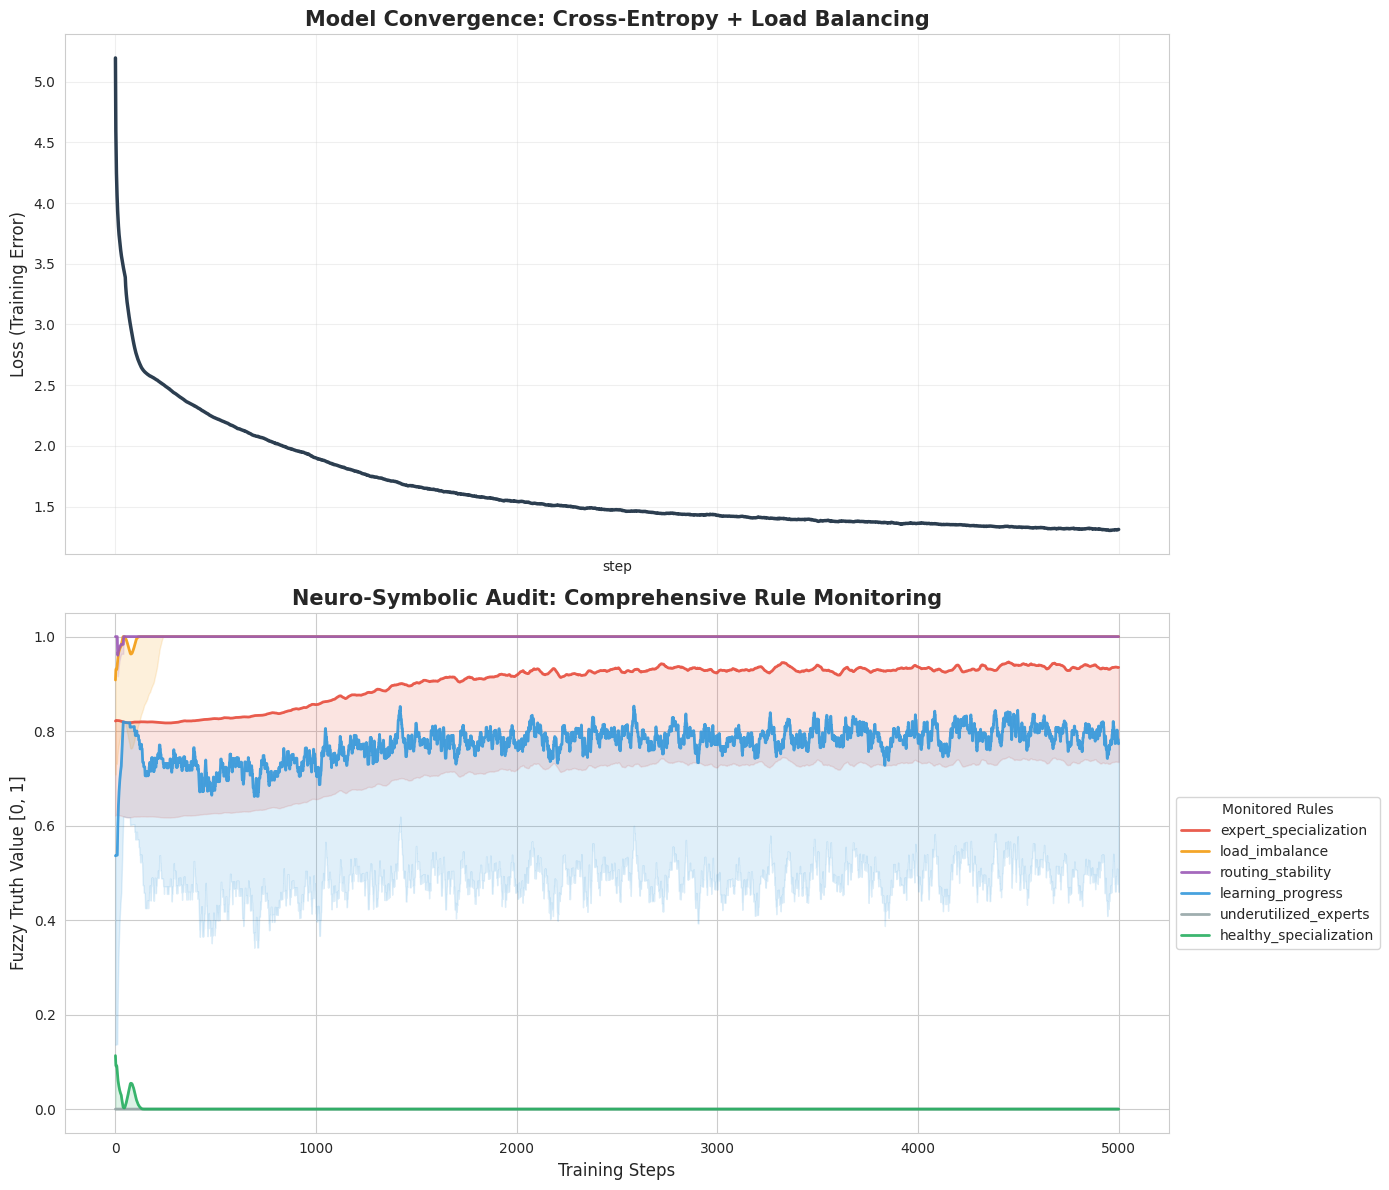

In [26]:
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# 1. PANEL: Convergence Model
history.loss.rolling(step=50, min_periods=1).mean().plot(ax=ax1, color='#2c3e50', lw=2.5)
ax1.set_title("Model Convergence: Cross-Entropy + Load Balancing", fontsize=15, fontweight='bold')
ax1.set_ylabel("Loss (Training Error)", fontsize=12)
ax1.grid(True, alpha=0.3)

# 2. PANEL: Neuro-Symbolic Audit
custom_colors = {
    "expert_specialization": "#e74c3c", # Red (target)
    "healthy_specialization": "#27ae60", # Green (ideal)
    "load_imbalance": "#f39c12",         # Orange (warning)
    "learning_progress": "#3498db",      # Blue
    "routing_stability": "#9b59b6",      # Purple
    "underutilized_experts": "#95a5a6"   # Gray
}

for r in rules_list:
    u_bound = history[f"{r}_U"].rolling(step=30, min_periods=1).mean()
    l_bound = history[f"{r}_L"].rolling(step=30, min_periods=1).mean()

    color = custom_colors.get(r, "black")
    line, = ax2.plot(history.step, u_bound, label=r, color=color, lw=2, alpha=0.9)
    ax2.fill_between(history.step, l_bound, u_bound, alpha=0.15, color=line.get_color())

ax2.set_title("Neuro-Symbolic Audit: Comprehensive Rule Monitoring", fontsize=15, fontweight='bold')
ax2.set_ylabel("Fuzzy Truth Value [0, 1]", fontsize=12)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Monitored Rules", fontsize=10)
ax2.set_xlabel("Training Steps", fontsize=12)

plt.tight_layout()
plt.show()